In [ ]:
import pandas as pd
import numpy as np

##1. Load the dataset

In [ ]:
df = pd.read_csv('/content/Maternal Health Risk Data Set.csv')

NameError: name 'pd' is not defined

####Display basic information

In [ ]:
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [ ]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']


In [ ]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


##2. Prepare the dataset

###Separate features and target

In [ ]:
X = df[
    [
        'Age',
        'SystolicBP',
        'DiastolicBP',
        'BS',
        'BodyTemp',
        'HeartRate'
    ]
]

In [ ]:
y = df['RiskLevel']

In [ ]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nRisk level distribution:")
print(y.value_counts())

Features shape: (1014, 6)
Target shape: (1014,)

Risk level distribution:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


###Enconde risk level to numerial representations

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

Classes:
['high risk' 'low risk' 'mid risk']


##3. Split into training and testing data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 811
Testing samples: 203


##4. Train the Logistic Regression Model

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


##5. Train the SVM

In [ ]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf'))
])

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

print("SVM trained successfully.")

SVM trained successfully.


##6. Train the Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


##7. Train the Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

decision_tree_predictions = decision_tree_model.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


##8. Evaluate the Four Models

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

models = {
    'Logistic Regression': logistic_predictions,
    'SVM': svm_predictions,
    'Random Forest': random_forest_predictions,
    'Decision Tree': decision_tree_predictions
}

results = []

for model_name, predictions in models.items():

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test,
        predictions,
        average='weighted',
        zero_division=0
    )
    recall = recall_score(
        y_test,
        predictions,
        average='weighted',
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        predictions,
        average='weighted',
        zero_division=0
    )

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.620690,0.608618,0.620690,0.603851
1,SVM,0.724138,0.743129,0.724138,0.708454
2,Random Forest,0.862069,0.868068,0.862069,0.863071
3,Decision Tree,0.837438,0.855618,0.837438,0.840048


##9. Get Detailed Classification Reports

In [ ]:
for model_name, predictions in models.items():

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

   high risk       0.78      0.78      0.78        55
    low risk       0.59      0.77      0.67        81
    mid risk       0.49      0.31      0.38        67

    accuracy                           0.62       203
   macro avg       0.62      0.62      0.61       203
weighted avg       0.61      0.62      0.60       203

SVM
              precision    recall  f1-score   support

   high risk       0.96      0.87      0.91        55
    low risk       0.63      0.90      0.74        81
    mid risk       0.70      0.39      0.50        67

    accuracy                           0.72       203
   macro avg       0.76      0.72      0.72       203
weighted avg       0.74      0.72      0.71       203

Random Forest
              precision    recall  f1-score   support

   high risk       0.96      0.95      0.95        55
    low risk       0.89      0.80      0.84        81
    mid risk       0.76      0.87    

##10. Confusion Matrices

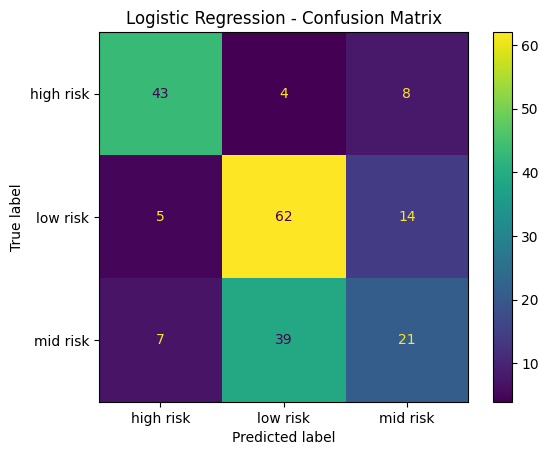

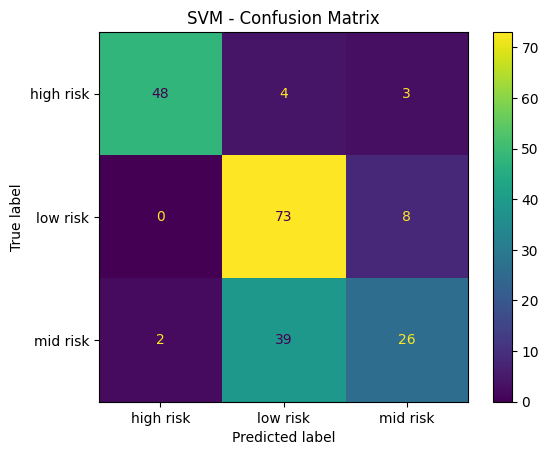

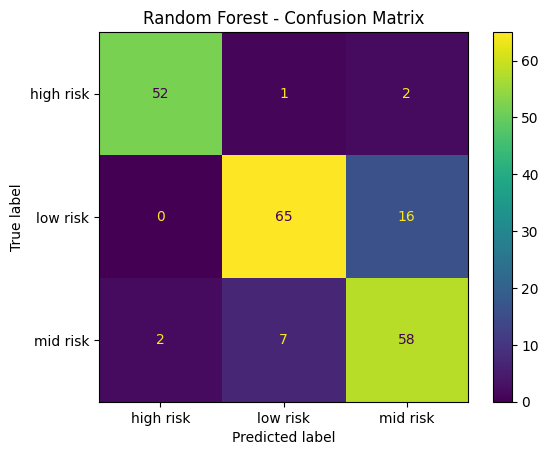

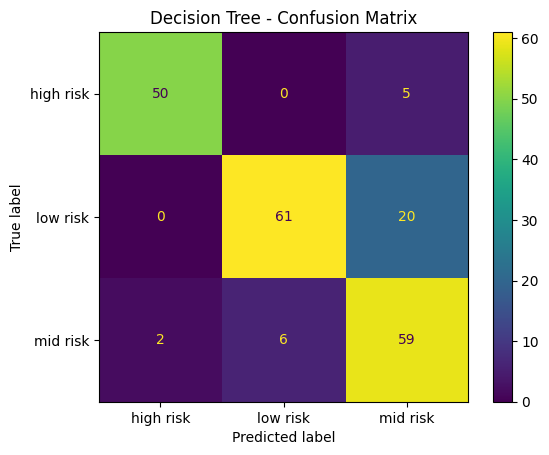

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for model_name, predictions in models.items():

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=label_encoder.classes_
    )

    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

##11. Compare the Models Visually

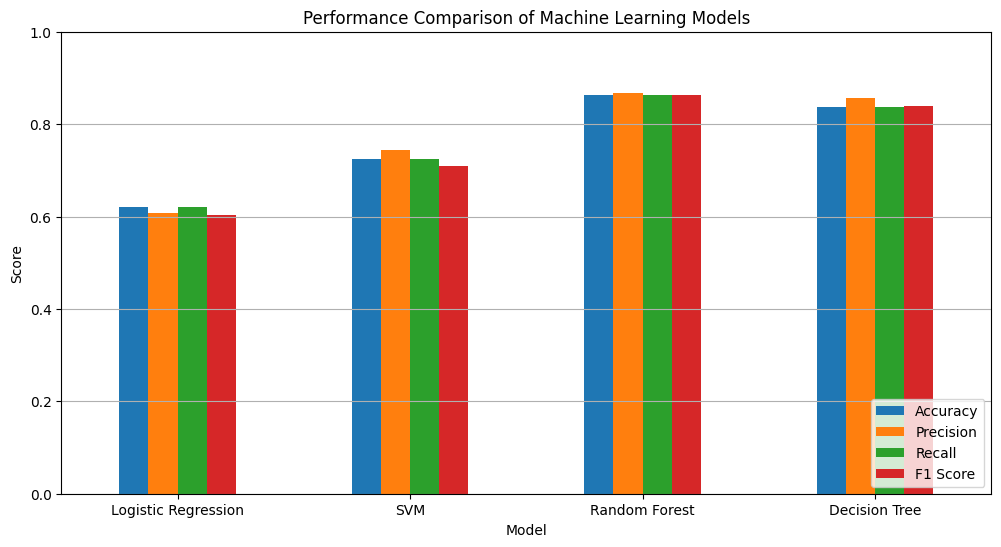

In [ ]:
results_plot = results_df.set_index('Model')

results_plot[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Performance Comparison of Machine Learning Models')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y')

plt.show()

##12. Feature Importance (Random Forest)

###For Random Forest, see which health measurements contributed most to its predictions.

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
3,BS,0.351597
1,SystolicBP,0.192600
0,Age,0.158901
2,DiastolicBP,0.127001
5,HeartRate,0.102978
4,BodyTemp,0.066923


###Plot the Random Forest feature importance graph

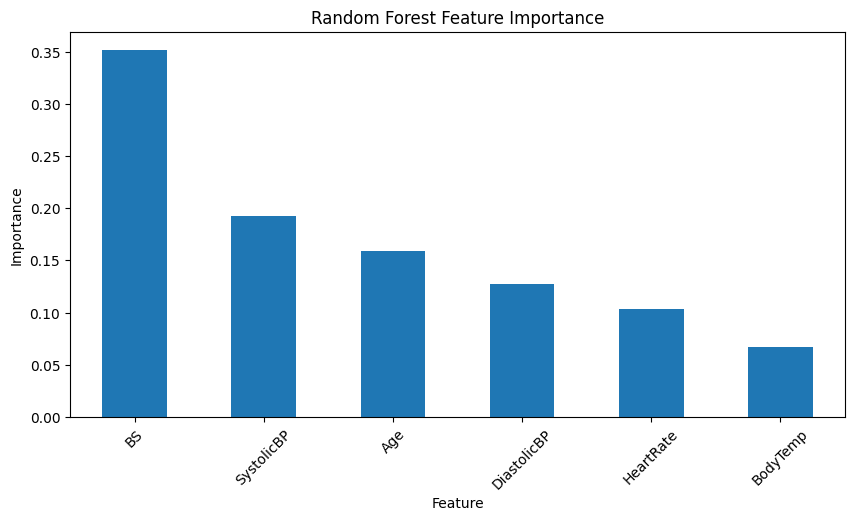

In [ ]:
feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10, 5),
    legend=False
)

plt.title('Random Forest Feature Importance')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=45)

plt.show()

##13. Test the Models using 5-fold Cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score

models_to_test = {
    'Logistic Regression': logistic_model,
    'SVM': svm_model,
    'Random Forest': random_forest_model,
    'Decision Tree': decision_tree_model
}

for name, model in models_to_test.items():

    scores = cross_val_score(
        model,
        X,
        y_encoded,
        cv=5,
        scoring='accuracy'
    )

    print(f"{name}")
    print(f"Fold accuracies: {scores}")
    print(f"Mean accuracy: {scores.mean():.4f}")
    print(f"Standard deviation: {scores.std():.4f}")
    print()

NameError: name 'logistic_model' is not defined

##16. Save the trained Random Forest from Colab

In [ ]:
import joblib

# Package everything needed for prediction
model_package = {
    "model": random_forest_model,
    "label_encoder": label_encoder,
    "features": [
        "Age",
        "SystolicBP",
        "DiastolicBP",
        "BS",
        "BodyTemp",
        "HeartRate"
    ]
}

# Save model package
joblib.dump(model_package, "maternal_health_risk_model.joblib")

print("Model saved successfully!")

NameError: name 'random_forest_model' is not defined

##17. Download the Model

In [ ]:
from google.colab import files

files.download("maternal_health_risk_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>